In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Loading the dataset
df = pd.read_csv('data_jobs.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
# Filtering the dataset for jobs in India
df_In = df[df['job_country'] == 'India'].copy()

In [4]:
# Exploding the job_skills column to create a new DataFrame with each skill in a separate row
df_skills = df_In.explode('job_skills')

df_skills[['job_title', 'job_skills']]

,job_title,job_skills
16,Big Data Engineer,powershell
16,Big Data Engineer,python
16,Big Data Engineer,sql
16,Big Data Engineer,mysql
16,Big Data Engineer,sql server
...,...,...
785716,Application Support Analyst,c#
785716,Application Support Analyst,sql
785718,Senior Performance QA Analyst,NaN
785740,AWS System Analyst,aws


In [5]:
# Dropping rows with NaN values in the job_skills column and resetting the index
df_skills = df_In.explode('job_skills')
df_skills = df_skills.dropna(subset=['job_skills'])
df_skills = df_skills.reset_index(drop=True)
df_skills[['job_title', 'job_skills']]

,job_title,job_skills
0,Big Data Engineer,powershell
1,Big Data Engineer,python
2,Big Data Engineer,sql
3,Big Data Engineer,mysql
4,Big Data Engineer,sql server
...,...,...
292396,India - Collections Analyst II,flow
292397,Application Support Analyst,c#
292398,Application Support Analyst,sql
292399,AWS System Analyst,aws


In [6]:
# Grouping the DataFrame by job_skills and job_title_short, counting the occurrences of each skill for each job title
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1374,sql,Data Engineer,12993
1088,python,Data Engineer,11568
1089,python,Data Scientist,9248
1327,spark,Data Engineer,7157
103,aws,Data Engineer,6993
...,...,...,...
34,angular.js,Data Scientist,1
49,arch,Business Analyst,1
787,mlpack,Data Engineer,1
1679,yarn,Senior Data Scientist,1


In [7]:
# Getting the unique job titles from the DataFrame and sorting them
job_titles = df_skills_count['job_title_short'].unique().tolist()

# Sorting the job titles and selecting the top 3
job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

### Most Demanded Skills for Top Roles
To determine the tech competencies most heavily sought after by employers, we isolate data roles within the localized Indian market. By unnseting and breaking down individual skill lists, this query evaluates the most frequent tools and libraries demanded across different target disciplines.
 Creating a bar plot for the top 5 skills for top 3 job titles in India.

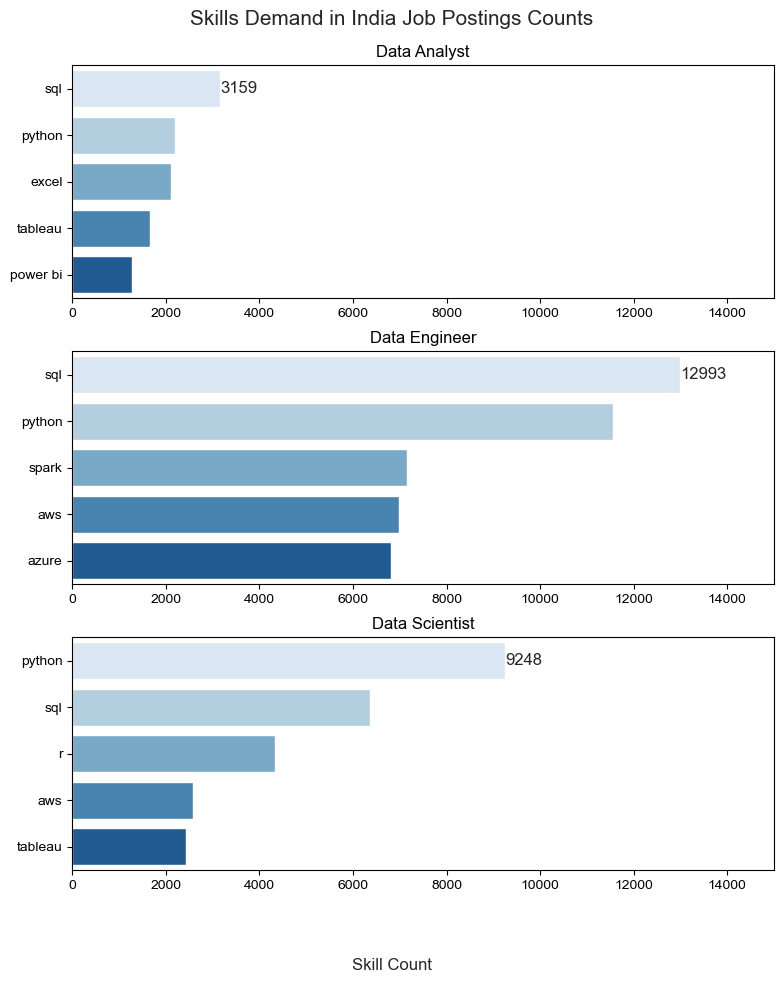

In [ ]:
# Creating subplots for each job title to visualize the top 5 skills in demand
fig, ax = plt.subplots(len(job_titles), 1, figsize=(8, 10))
sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title] \
                .nlargest(5, 'skill_count')   # Get the top 5 skills for each job title


    palette = sns.color_palette("Blues", n_colors=len(df_plot)) # Create a color palette for the bars based on the number of skills

    bars = sns.barplot(
        data=df_plot,
        x='skill_count',    # Set the x-axis to the skill count
        y='job_skills',     # Set the y-axis to the job skills
        ax=ax[i],
        hue='job_skills',   # Set the hue to the job skills to differentiate the bars
        palette=palette,
        legend=False
    )

    ax[i].set_title(job_title)   # Set the title of each subplot to the job title
    ax[i].set_ylabel('')         # Set the y-axis label
    ax[i].set_xlabel('')         # Set the x-axis label
    ax[i].set_xlim(0, 15000)     # Set the x-axis limit to 15000 for better visualization
    ax[i].bar_label(bars.containers[0], fmt='%d')

fig.suptitle('Skills Demand in India Job Postings Counts', fontsize=15)  # Set the overall title for the figure
fig.text(0.5, 0.02, 'Skill Count', ha='center')                          # Set the x-axis label for the entire figure
fig.tight_layout(h_pad=1)                                                # Adjust the layout of the subplots to prevent overlap
plt.subplots_adjust(bottom=0.12)
plt.show() 

In [9]:
# Getting the total number of jobs for each job title in India
df_job_title_count = df_In['job_title_short'].value_counts().reset_index(name='jobs_total')

df_job_title_count

,job_title_short,jobs_total
0,Data Engineer,19062
1,Data Scientist,13279
2,Data Analyst,6121
3,Senior Data Engineer,4353
4,Senior Data Scientist,2486
5,Business Analyst,1887
6,Software Engineer,1795
7,Senior Data Analyst,1083
8,Machine Learning Engineer,671
9,Cloud Engineer,351


In [10]:
# Merging the skills count DataFrame with the job title count DataFrame to calculate the percentage of jobs that require each skill for each job title
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, on='job_title_short', how='left')

# Calculating the percentage of jobs that require each skill for each job title
df_skills_perc['skill_percent'] = (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) * 100

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,sql,Data Engineer,12993,19062,68.161788
1,python,Data Engineer,11568,19062,60.686182
2,python,Data Scientist,9248,13279,69.643798
3,spark,Data Engineer,7157,19062,37.545903
4,aws,Data Engineer,6993,19062,36.685552
...,...,...,...,...,...
1684,angular.js,Data Scientist,1,13279,0.007531
1685,arch,Business Analyst,1,1887,0.052994
1686,mlpack,Data Engineer,1,19062,0.005246
1687,yarn,Senior Data Scientist,1,2486,0.040225


Creating a bar plot for the top 5 skills for top 3 job titles in India based on percentage of jobs that require each skill.

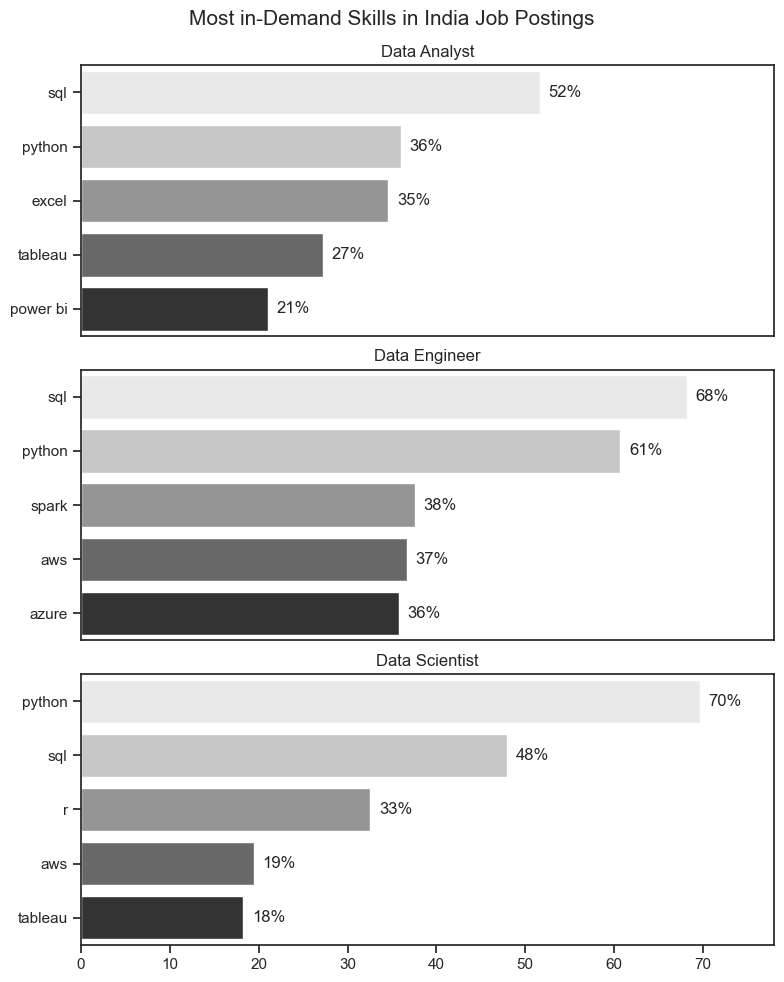

In [ ]:
# Creating subplots for each job title to visualize the top 5 skills in demand by percentage
fig, ax = plt.subplots(len(job_titles), 1, figsize=(8, 10))
sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    df_plot = df_plot.sort_values('skill_percent', ascending=False)  # Sort the DataFrame by skill_percent in descending order for better visualization

    palette = sns.color_palette("Greys", n_colors=len(df_plot)) 

    bars = sns.barplot(
        data=df_plot,
        x='skill_percent',                  # Set the x-axis to the skill percentage
        y='job_skills',                     # Set the y-axis to the job skills
        ax=ax[i],
        hue='job_skills',
        palette=palette,
        legend=False
    )

    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0, 78)

    if i != len(job_titles) - 1:    # If it's not the last subplot, remove the x-ticks to avoid clutter
        ax[i].set_xticks([])        # Remove x-ticks

    for n, v in enumerate(df_plot['skill_percent']):            # Loop through the skill percentages and their corresponding indices
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')          # Add text labels to the bars with the skill percentage, positioned slightly to the right of the bar

fig.suptitle('Most in-Demand Skills in India Job Postings', fontsize=15) 
fig.tight_layout(h_pad=.8)
plt.show()

Plotting the most in-demand skills for each job title.

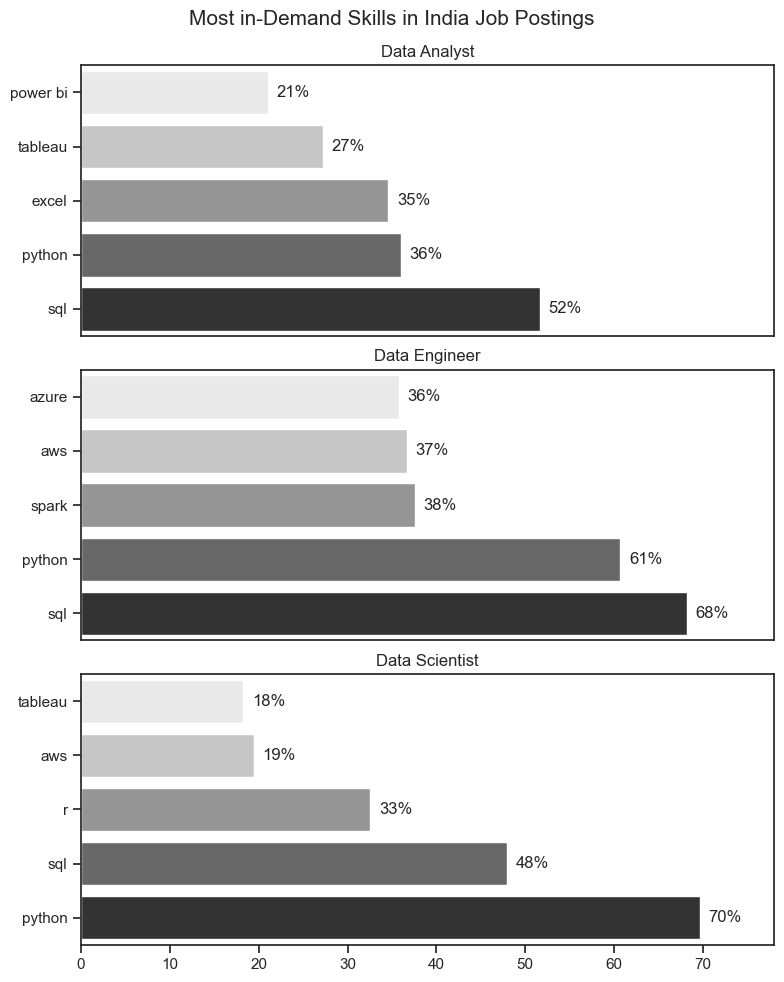

In [ ]:
# setting up the subplots for each job title to visualize the top 5 skills in demand by percentage
fig, ax = plt.subplots(len(job_titles), 1, figsize=(8, 10))
sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    df_plot = df_plot.sort_values('skill_percent') # ascending is true by default, so the skill with the lowest percentage will be at the top of the bar plot

    palette = sns.color_palette("Greys", n_colors=len(df_plot))

    bars = sns.barplot(
        data=df_plot,
        x='skill_percent',
        y='job_skills',
        ax=ax[i],
        hue='job_skills',
        palette=palette,
        legend=False
    )

    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0, 78)

    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Most in-Demand Skills in India Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show() 